## Importation

In [1]:
import os
import glob
import time
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
    pairwise_distances,
)
from sklearn.metrics.pairwise import euclidean_distances

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from typing import Tuple, Dict, Any, Optional


/home/yona/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Shared utilities - run before anything else

In [9]:
DATA_ROOT    = '/media/Data/Yona/WSI CCRCC'
CSV_PATH     = f'{DATA_ROOT}/medical_genomic_data/clinical+genomic_split.csv'
FEATURES_DIR = f'{DATA_ROOT}/WSI_features_MaxPooling'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class WSIEmbeddingDataset(Dataset):
    def __init__(self, csv_path: str, features_dir: str, split: str = 'train'):
        df     = pd.read_csv(csv_path)[['case_id', 'vital_status_12', 'Split']]
        wanted = split.strip().lower()
        data_list = []
        for _, row in df.iterrows():
            case_id = str(row['case_id']).strip()
            label   = int(row['vital_status_12'])
            if str(row['Split']).strip().lower() != wanted:
                continue
            if case_id.startswith('C'):
                patient_id = case_id
            elif case_id.startswith('T'):
                parts = case_id.split('-')
                if len(parts) < 3:
                    continue
                patient_id = '-'.join(parts[:3])
            else:
                continue
            for fp in glob.glob(os.path.join(features_dir, f'{patient_id}-*.npz')):
                data_list.append({'patient_id': patient_id, 'vital_status': label, 'file_path': fp})
        self.data_list = data_list

    def __len__(self) -> int:
        return len(self.data_list)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        item = self.data_list[idx]
        feat = np.load(item['file_path'])['features']
        if feat.ndim == 1:
            feat = feat[np.newaxis]
        return {
            'patient_id': item['patient_id'],
            'embedding':  torch.tensor(feat[0], dtype=torch.float32),
            'label':      item['vital_status'],
            'file_path':  item['file_path'],
        }


class CombinedWSIDataset(Dataset):
    def __init__(self, ds_train: WSIEmbeddingDataset, ds_val: WSIEmbeddingDataset):
        self.ds_train  = ds_train
        self.ds_val    = ds_val
        self.train_len = len(ds_train)
        self.data_list = ds_train.data_list + ds_val.data_list

    def __len__(self) -> int:
        return self.train_len + len(self.ds_val)

    def __getitem__(self, idx: int):
        return self.ds_train[idx] if idx < self.train_len else self.ds_val[idx - self.train_len]


class TripletDataset(Dataset):
    def __init__(self, triplets_file: str, embedding_dataset: Dataset):
        with open(triplets_file, 'rb') as f:
            self.triplets = pickle.load(f)
        self.embedding_dataset = embedding_dataset

    def __len__(self) -> int:
        return len(self.triplets)

    def __getitem__(self, idx: int):
        a, p, n = self.triplets[idx]
        return (
            self.embedding_dataset[a]['embedding'],
            self.embedding_dataset[p]['embedding'],
            self.embedding_dataset[n]['embedding'],
        )


class DeepEmbeddingNet(nn.Module):
    def __init__(self, input_dim: int = 2048, embedding_dim: int = 256, dropout: float = 0.3):
        super().__init__()
        self.fc1     = nn.Linear(input_dim, 1024)
        self.fc2     = nn.Linear(1024, 512)
        self.fc3     = nn.Linear(512, embedding_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        return F.normalize(self.fc3(x), p=2, dim=1)


class AugmentedPatientDataset(Dataset):
    def __init__(self, embeddings: np.ndarray, labels: np.ndarray,
                 augment: bool = False, noise_std: float = 0.0, augment_factor: int = 1):
        self.augment        = augment
        self.noise_std      = float(noise_std)
        self.augment_factor = int(augment_factor)
        if augment:
            emb_list, lbl_list = [], []
            for emb, lbl in zip(embeddings, labels):
                copies = self.augment_factor if int(lbl) == 0 else 1
                for _ in range(copies):
                    emb_list.append(emb)
                    lbl_list.append(int(lbl))
            self.embeddings = np.array(emb_list, dtype=np.float32)
            self.labels     = np.array(lbl_list, dtype=np.int64)
        else:
            self.embeddings = np.array(embeddings, dtype=np.float32)
            self.labels     = np.array(labels, dtype=np.int64)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int):
        emb = self.embeddings[idx].copy()
        y   = int(self.labels[idx])
        if self.augment and y == 0 and self.noise_std > 0:
            emb += np.random.normal(0, self.noise_std, size=emb.shape).astype(np.float32)
        return torch.tensor(emb, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


class PatientMLP(nn.Module):
    """Shared MLP classifier for Optuna search and final training."""
    def __init__(self, input_dim: int, hidden_dims: list, dropouts: list):
        super().__init__()
        assert len(hidden_dims) == len(dropouts)
        layers, prev = [], input_dim
        for h, d in zip(hidden_dims, dropouts):
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(p=float(d))]
            prev = h
        layers.append(nn.Linear(prev, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def build_patient_dict(dataset) -> Dict:
    patient_dict: Dict = {}
    for idx, item in enumerate(dataset.data_list):
        pid, label = item['patient_id'], int(item['vital_status'])
        if pid in patient_dict:
            patient_dict[pid][1].append(idx)
        else:
            patient_dict[pid] = (label, [idx])
    return patient_dict


def oversample_patient_dict(patient_dict: Dict) -> Dict:
    total0 = sum(len(i) for lbl, i in patient_dict.values() if lbl == 0)
    total1 = sum(len(i) for lbl, i in patient_dict.values() if lbl == 1)
    if total0 == 0 or total0 >= total1:
        return patient_dict
    factor = int(np.ceil(total1 / total0))
    return {pid: (lbl, idxs * factor if lbl == 0 else idxs) for pid, (lbl, idxs) in patient_dict.items()}


def generate_triplets(patient_dict: Dict, seed: int = 42) -> list:
    random.seed(seed)
    pids0 = [p for p, (l, _) in patient_dict.items() if l == 0]
    pids1 = [p for p, (l, _) in patient_dict.items() if l == 1]
    triplets = []
    for pid, (label, indices) in patient_dict.items():
        if len(indices) < 2:
            continue
        neg_pool = pids0 if label == 1 else pids1
        if not neg_pool:
            continue
        for anc in indices:
            pos = random.choice([i for i in indices if i != anc])
            neg = random.choice(patient_dict[random.choice(neg_pool)][1])
            triplets.append((anc, pos, neg))
    return triplets


def aggregate_maxpool(X: np.ndarray, y: np.ndarray, pids: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    agg: Dict = {}
    for emb, lbl, pid in zip(X, y, pids):
        if pid not in agg:
            agg[pid] = {'embs': [], 'label': int(lbl)}
        agg[pid]['embs'].append(emb)
    return (
        np.stack([np.max(np.stack(v['embs']), 0) for v in agg.values()]).astype(np.float32),
        np.array([v['label'] for v in agg.values()], dtype=np.int64),
    )


def load_triplet_model(path: str) -> Tuple[nn.Module, Dict]:
    ckpt  = torch.load(path, map_location='cpu')
    cfg   = ckpt['cfg']
    model = DeepEmbeddingNet(input_dim=2048, embedding_dim=cfg['embedding_dim'], dropout=cfg['dropout']).to(device)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    print('Loaded triplet model cfg:', cfg)
    return model, cfg


@torch.no_grad()
def extract_embeddings(split: str, triplet_model: nn.Module, batch_size: int = 512) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    ds     = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split=split)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
    Zs, ys, ps = [], [], []
    for batch in loader:
        Zs.append(triplet_model(batch['embedding'].to(device)).cpu().numpy())
        ys.append(np.array(batch['label']))
        ps.append(np.array(batch['patient_id']))
    return np.concatenate(Zs).astype(np.float32), np.concatenate(ys).astype(np.int64), np.concatenate(ps)


Using device: cuda


## 1. Generate train triplets

In [10]:
set_seed(42)

ds_train           = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='train')
patient_dict_train = build_patient_dict(ds_train)
patient_dict_train = oversample_patient_dict(patient_dict_train)
triplets_train     = generate_triplets(patient_dict_train, seed=42)

print(f'Train embeddings: {len(ds_train)}')
print(f'Train patients  : {len({d["patient_id"] for d in ds_train.data_list})}')
print(f'Train triplets  : {len(triplets_train)}')

train_triplets_path = f'{DATA_ROOT}/triplets_from_embeddings.pkl'
with open(train_triplets_path, 'wb') as f:
    pickle.dump(triplets_train, f)
print('Saved to:', train_triplets_path)


Train embeddings: 1636
Train patients  : 472
Train triplets  : 2926
Saved to: /media/Data/Yona/WSI CCRCC/triplets_from_embeddings.pkl


## 2. Generate validation triplets

In [11]:
set_seed(42)

ds_val           = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='validation')
patient_dict_val = build_patient_dict(ds_val)
triplets_val     = generate_triplets(patient_dict_val, seed=42)

n0 = sum(1 for _, (l, _) in patient_dict_val.items() if l == 0)
n1 = sum(1 for _, (l, _) in patient_dict_val.items() if l == 1)
print(f'Validation patients: {len(patient_dict_val)} | label0={n0} | label1={n1}')
print(f'Validation triplets: {len(triplets_val)}')

val_triplets_path = f'{DATA_ROOT}/triplets_validation.pkl'
with open(val_triplets_path, 'wb') as f:
    pickle.dump(triplets_val, f)
print('Saved to:', val_triplets_path)


Validation patients: 25 | label0=3 | label1=22
Validation triplets: 81
Saved to: /media/Data/Yona/WSI CCRCC/triplets_validation.pkl


## 3. Manual grid search - triplet model

In [5]:
train_triplets_path = f'{DATA_ROOT}/triplets_from_embeddings.pkl'
val_triplets_path   = f'{DATA_ROOT}/triplets_validation.pkl'


def _train_triplet_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total = 0.0
    for anc, pos, neg in loader:
        anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
        loss = loss_fn(model(anc), model(pos), model(neg))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / max(len(loader), 1)


@torch.no_grad()
def _eval_triplet_epoch(model, loader, loss_fn):
    model.eval()
    total = 0.0
    for anc, pos, neg in loader:
        total += loss_fn(model(anc.to(device)), model(pos.to(device)), model(neg.to(device))).item()
    return total / max(len(loader), 1)


def run_trial(cfg, num_epochs=15, patience=4, seed=42):
    set_seed(seed)
    ds_tr = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='train')
    ds_va = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='validation')
    tr_loader = DataLoader(TripletDataset(train_triplets_path, ds_tr), batch_size=cfg['batch_size'], shuffle=True,  drop_last=True)
    va_loader = DataLoader(TripletDataset(val_triplets_path,   ds_va), batch_size=cfg['batch_size'], shuffle=False, drop_last=False)
    model     = DeepEmbeddingNet(input_dim=2048, embedding_dim=cfg['embedding_dim'], dropout=cfg['dropout']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    loss_fn   = nn.TripletMarginLoss(margin=cfg['margin'], p=2)
    best_val, best_state, bad = float('inf'), None, 0
    for epoch in range(num_epochs):
        tr = _train_triplet_epoch(model, tr_loader, optimizer, loss_fn)
        va = _eval_triplet_epoch(model, va_loader, loss_fn)
        print(f'    epoch {epoch+1}/{num_epochs} | train={tr:.4f} | val={va:.4f}')
        if va < best_val - 1e-4:
            best_val, bad = va, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    return best_val, best_state


search_space = [
    {'lr': 1e-4, 'margin': 0.2, 'embedding_dim': 128, 'dropout': 0.2, 'batch_size': 32, 'weight_decay': 1e-4},
    {'lr': 3e-4, 'margin': 0.3, 'embedding_dim': 128, 'dropout': 0.2, 'batch_size': 32, 'weight_decay': 1e-4},
    {'lr': 1e-3, 'margin': 0.5, 'embedding_dim': 128, 'dropout': 0.2, 'batch_size': 32, 'weight_decay': 1e-4},
    {'lr': 3e-4, 'margin': 0.2, 'embedding_dim': 256, 'dropout': 0.3, 'batch_size': 64, 'weight_decay': 1e-4},
    {'lr': 1e-4, 'margin': 0.5, 'embedding_dim':  64, 'dropout': 0.0, 'batch_size': 64, 'weight_decay': 1e-5},
]

best_cfg, best_val, best_state_gs = None, float('inf'), None
for i, cfg in enumerate(search_space, 1):
    print(f'\n=== Trial {i}/{len(search_space)} === {cfg}')
    val_loss, state = run_trial(cfg, num_epochs=15, patience=4)
    print(f'  -> val_loss: {val_loss:.4f}')
    if val_loss < best_val:
        best_val, best_cfg, best_state_gs = val_loss, cfg, state

print('\nBest cfg:', best_cfg, '| val_loss:', best_val)



=== Trial 1/5 === {'lr': 0.0001, 'margin': 0.2, 'embedding_dim': 128, 'dropout': 0.2, 'batch_size': 32, 'weight_decay': 0.0001}


    epoch 1/15 | train=0.1432 | val=0.0789
    epoch 2/15 | train=0.0999 | val=0.0773
    epoch 3/15 | train=0.0870 | val=0.0826
    epoch 4/15 | train=0.0749 | val=0.0811
    epoch 5/15 | train=0.0631 | val=0.0817
    epoch 6/15 | train=0.0551 | val=0.0755
    epoch 7/15 | train=0.0502 | val=0.0875
    epoch 8/15 | train=0.0410 | val=0.0962
    epoch 9/15 | train=0.0389 | val=0.0770
    epoch 10/15 | train=0.0356 | val=0.0852
  -> val_loss: 0.0755

=== Trial 2/5 === {'lr': 0.0003, 'margin': 0.3, 'embedding_dim': 128, 'dropout': 0.2, 'batch_size': 32, 'weight_decay': 0.0001}
    epoch 1/15 | train=0.2263 | val=0.1674
    epoch 2/15 | train=0.1446 | val=0.1266
    epoch 3/15 | train=0.1275 | val=0.1425
    epoch 4/15 | train=0.1030 | val=0.1414
    epoch 5/15 | train=0.0913 | val=0.1425
    epoch 6/15 | train=0.0842 | val=0.1117
    epoch 7/15 | train=0.0908 | val=0.1070
    epoch 8/15 | train=0.0999 | val=0.1202
    epoch 9/15 | train=0.0963 | val=0.1193
    epoch 10/15 | train=0.0984 

## 4. Final triplet model - train on train + validation

In [21]:
BEST_CFG = {
    'lr':            0.0003,
    'margin':        0.2,
    'embedding_dim': 256,
    'dropout':       0.3,
    'batch_size':    64,
    'weight_decay':  0.0001,
}

set_seed(42)

ds_train    = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='train')
ds_val      = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='validation')
ds_trainval = CombinedWSIDataset(ds_train, ds_val)
print(f'Combined: {len(ds_trainval)} embeddings | {len({d["patient_id"] for d in ds_trainval.data_list})} patients')

patient_dict_tv = build_patient_dict(ds_trainval)
patient_dict_tv = oversample_patient_dict(patient_dict_tv)
triplets_tv     = generate_triplets(patient_dict_tv, seed=42)
print(f'Train+val triplets: {len(triplets_tv)}')

triplets_tv_path = f'{DATA_ROOT}/triplets_trainval.pkl'
with open(triplets_tv_path, 'wb') as f:
    pickle.dump(triplets_tv, f)

triplet_loader = DataLoader(
    TripletDataset(triplets_tv_path, ds_trainval),
    batch_size=BEST_CFG['batch_size'], shuffle=True, drop_last=True, num_workers=0,
)

model     = DeepEmbeddingNet(input_dim=2048, embedding_dim=BEST_CFG['embedding_dim'], dropout=BEST_CFG['dropout']).to(device)
optimizer = optim.Adam(model.parameters(), lr=BEST_CFG['lr'], weight_decay=BEST_CFG['weight_decay'])
loss_fn   = nn.TripletMarginLoss(margin=BEST_CFG['margin'], p=2)

NUM_EPOCHS = 20
model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for anc, pos, neg in triplet_loader:
        anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
        loss = loss_fn(model(anc), model(pos), model(neg))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | loss={epoch_loss / max(len(triplet_loader), 1):.4f}')

final_model_path = f'{DATA_ROOT}/triplet_model_final_trainval.pth'
torch.save({'cfg': BEST_CFG, 'state_dict': model.state_dict()}, final_model_path)
print('Saved FINAL triplet model to:', final_model_path)


Combined: 1719 embeddings | 497 patients
Train+val triplets: 3073
Epoch 1/20 | loss=0.1946
Epoch 2/20 | loss=0.1324
Epoch 3/20 | loss=0.1068
Epoch 4/20 | loss=0.0964
Epoch 5/20 | loss=0.0879
Epoch 6/20 | loss=0.0834
Epoch 7/20 | loss=0.0718
Epoch 8/20 | loss=0.0652
Epoch 9/20 | loss=0.0655
Epoch 10/20 | loss=0.0620
Epoch 11/20 | loss=0.0647
Epoch 12/20 | loss=0.0646
Epoch 13/20 | loss=0.0643
Epoch 14/20 | loss=0.0631
Epoch 15/20 | loss=0.0663
Epoch 16/20 | loss=0.0728
Epoch 17/20 | loss=0.0765
Epoch 18/20 | loss=0.0657
Epoch 19/20 | loss=0.0645
Epoch 20/20 | loss=0.0638
Saved FINAL triplet model to: /media/Data/Yona/WSI CCRCC/triplet_model_final_trainval.pth


## 5. Embedding visualization (t-SNE + pairwise metrics)

Loaded triplet model cfg: {'lr': 0.0003, 'margin': 0.2, 'embedding_dim': 256, 'dropout': 0.3, 'batch_size': 64, 'weight_decay': 0.0001}


/tmp/ipykernel_3149883/78064053.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))
/tmp/ipykernel_3149883/78064053.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))



--- ORIGINAL 2048 ---
Train+Val: {'N_used': 1719, 'cosine_intra': 0.14000190794467926, 'cosine_inter': 0.13492444157600403, 'euclidean_intra': 0.5228419303894043, 'euclidean_inter': 0.5135071873664856, 'delta_cosine': -0.005077466368675232, 'delta_euclidean': -0.009334743022918701, 'per_class': {0: {'n': 229, 'cosine_intra': 0.12716209888458252, 'cosine_inter': 0.13492447137832642, 'euclidean_intra': 0.4975893199443817, 'euclidean_inter': 0.5135071873664856, 'delta_cosine': 0.0077623724937438965, 'delta_euclidean': 0.015917867422103882}, 1: {'n': 1490, 'cosine_intra': 0.1403041034936905, 'cosine_inter': 0.13492445647716522, 'euclidean_intra': 0.5234361886978149, 'euclidean_inter': 0.5135071873664856, 'delta_cosine': -0.0053796470165252686, 'delta_euclidean': -0.009929001331329346}}}
Test:      {'N_used': 415, 'cosine_intra': 0.13609325885772705, 'cosine_inter': 0.13394513726234436, 'euclidean_intra': 0.5145640969276428, 'euclidean_inter': 0.5120699405670166, 'delta_cosine': -0.0021481

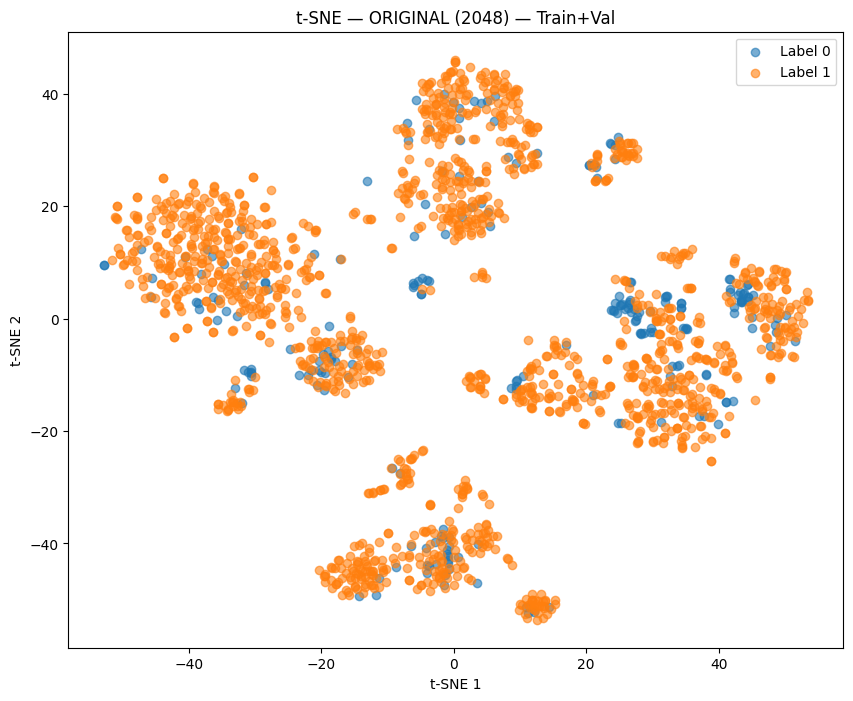

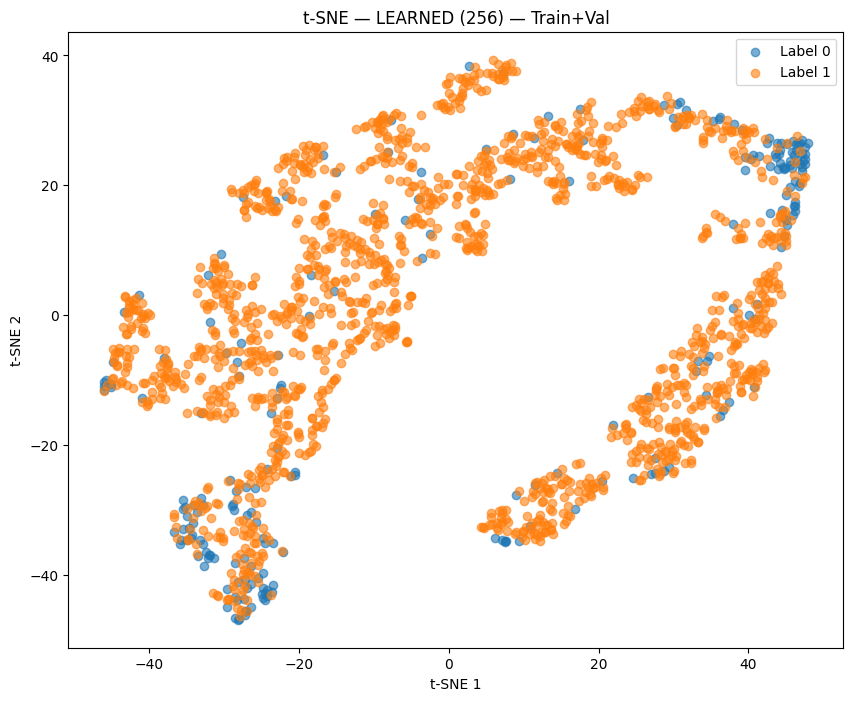

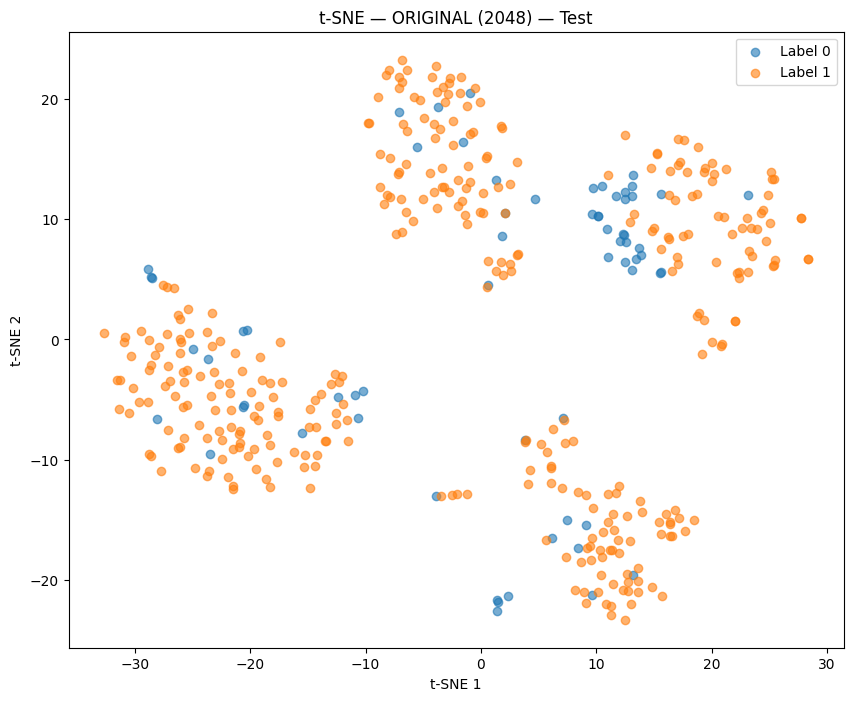

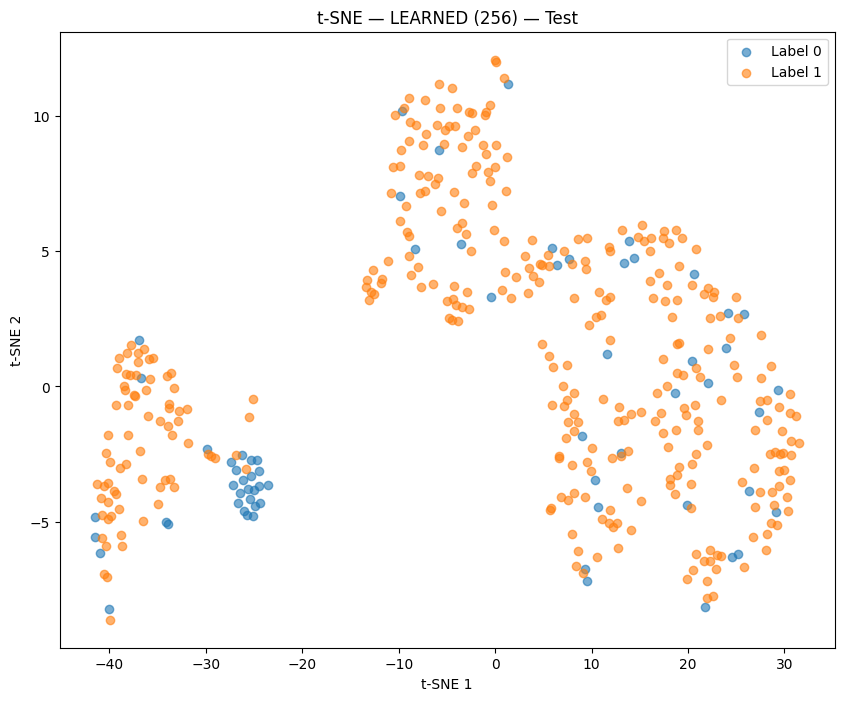

In [24]:
set_seed(42)

ds_train    = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='train')
ds_val      = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='validation')
ds_trainval = CombinedWSIDataset(ds_train, ds_val)
ds_test     = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='test')

final_model_path    = f'{DATA_ROOT}/triplet_model_final_trainval.pth'
triplet_model, _    = load_triplet_model(final_model_path)


def collect_original_embeddings(dataset, batch_size=512):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
    Xs, ys, ps = [], [], []
    for batch in loader:
        Xs.append(batch['embedding'].numpy())
        ys.append(np.array(batch['label']))
        ps.append(np.array(batch['patient_id']))
    return np.concatenate(Xs).astype(np.float32), np.concatenate(ys).astype(np.int64), np.concatenate(ps)


@torch.no_grad()
def collect_transformed_embeddings(dataset, model, batch_size=512):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
    Zs, ys, ps = [], [], []
    for batch in loader:
        Zs.append(model(batch['embedding'].to(device)).cpu().numpy())
        ys.append(np.array(batch['label']))
        ps.append(np.array(batch['patient_id']))
    return np.concatenate(Zs).astype(np.float32), np.concatenate(ys).astype(np.int64), np.concatenate(ps)


def _mean_upper_triangle(mat):
    n = mat.shape[0]
    if n < 2:
        return float('nan'), 0
    vals = mat[np.triu_indices(n, k=1)]
    return (float(np.mean(vals)) if vals.size > 0 else float('nan')), int(vals.size)


def _mean_between_blocks(mat, ia, ib):
    if len(ia) == 0 or len(ib) == 0:
        return float('nan'), 0
    block = mat[np.ix_(ia, ib)]
    return float(np.mean(block)), int(block.size)


def compute_pairwise_metrics(X, y, max_points=3000, seed=42):
    set_seed(seed)
    if X.shape[0] > max_points:
        idx = np.random.choice(X.shape[0], size=max_points, replace=False)
        X, y = X[idx], y[idx]
    N       = X.shape[0]
    cos_mat = pairwise_distances(X, metric='cosine')
    euc_mat = euclidean_distances(X)
    triu    = np.triu_indices(N, k=1)
    same    = y[triu[0]] == y[triu[1]]
    ic, xc  = cos_mat[triu][same],  cos_mat[triu][~same]
    ie, xe  = euc_mat[triu][same],  euc_mat[triu][~same]
    out = {
        'N_used':           N,
        'cosine_intra':     float(np.mean(ic)) if ic.size else float('nan'),
        'cosine_inter':     float(np.mean(xc)) if xc.size else float('nan'),
        'euclidean_intra':  float(np.mean(ie)) if ie.size else float('nan'),
        'euclidean_inter':  float(np.mean(xe)) if xe.size else float('nan'),
        'delta_cosine':     float(np.mean(xc) - np.mean(ic)) if (ic.size and xc.size) else float('nan'),
        'delta_euclidean':  float(np.mean(xe) - np.mean(ie)) if (ie.size and xe.size) else float('nan'),
        'per_class':        {},
    }
    for c in np.unique(y):
        ic_idx, nc_idx = np.where(y == c)[0], np.where(y != c)[0]
        ci,  _ = _mean_upper_triangle(cos_mat[np.ix_(ic_idx, ic_idx)])
        cx,  _ = _mean_between_blocks(cos_mat, ic_idx, nc_idx)
        ei,  _ = _mean_upper_triangle(euc_mat[np.ix_(ic_idx, ic_idx)])
        ex,  _ = _mean_between_blocks(euc_mat, ic_idx, nc_idx)
        out['per_class'][int(c)] = {
            'n': len(ic_idx),
            'cosine_intra': ci,   'cosine_inter': cx,
            'euclidean_intra': ei, 'euclidean_inter': ex,
            'delta_cosine': float(cx - ci) if not (np.isnan(cx) or np.isnan(ci)) else float('nan'),
            'delta_euclidean': float(ex - ei) if not (np.isnan(ex) or np.isnan(ei)) else float('nan'),
        }
    return out


def plot_tsne(X, y, title, max_points=3000, seed=42):
    set_seed(seed)
    if X.shape[0] > max_points:
        idx = np.random.choice(X.shape[0], size=max_points, replace=False)
        X, y = X[idx], y[idx]
    X2 = TSNE(n_components=2, random_state=seed, init='pca', learning_rate='auto').fit_transform(X)
    plt.figure(figsize=(10, 8))
    plt.scatter(X2[y == 0, 0], X2[y == 0, 1], alpha=0.6, label='Label 0')
    plt.scatter(X2[y == 1, 0], X2[y == 1, 1], alpha=0.6, label='Label 1')
    plt.title(title); plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.legend(); plt.show()


X_tv, y_tv, _ = collect_original_embeddings(ds_trainval)
X_te, y_te, _ = collect_original_embeddings(ds_test)
norm = lambda X: X / np.clip(np.linalg.norm(X, axis=1, keepdims=True), 1e-12, None)
X_tv_n, X_te_n = norm(X_tv), norm(X_te)

Z_tv, y_tv2, _ = collect_transformed_embeddings(ds_trainval, triplet_model)
Z_te, y_te2, _ = collect_transformed_embeddings(ds_test,     triplet_model)

print('\n--- ORIGINAL 2048 ---')
print('Train+Val:', compute_pairwise_metrics(X_tv_n, y_tv))
print('Test:     ', compute_pairwise_metrics(X_te_n, y_te))

print('\n--- LEARNED 256 ---')
print('Train+Val:', compute_pairwise_metrics(Z_tv, y_tv2))
print('Test:     ', compute_pairwise_metrics(Z_te, y_te2))

plot_tsne(X_tv_n, y_tv,  't-SNE — ORIGINAL (2048) — Train+Val')
plot_tsne(Z_tv,   y_tv2, 't-SNE — LEARNED (256) — Train+Val')
plot_tsne(X_te_n, y_te,  't-SNE — ORIGINAL (2048) — Test')
plot_tsne(Z_te,   y_te2, 't-SNE — LEARNED (256) — Test')


## 6. Optuna hyperparameter search - MLP classifier

In [25]:
final_triplet_path = f'{DATA_ROOT}/triplet_model_final_trainval.pth'
OBJECTIVE_NAME     = 'custom_score'  # or 'macro_f1'

set_seed(42)
triplet_model, triplet_cfg = load_triplet_model(final_triplet_path)

Z_train, y_train, pid_train = extract_embeddings('train',      triplet_model)
Z_val,   y_val,   pid_val   = extract_embeddings('validation', triplet_model)

X_train_agg, y_train_agg = aggregate_maxpool(Z_train, y_train, pid_train)
X_val_agg,   y_val_agg   = aggregate_maxpool(Z_val,   y_val,   pid_val)
print(f'Patients train={X_train_agg.shape[0]} val={X_val_agg.shape[0]}')


def _cls_train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, total = 0.0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * Xb.size(0)
        total += yb.size(0)
    return running_loss / max(total, 1)


@torch.no_grad()
def eval_metrics_with_threshold(model, loader, threshold=0.5):
    model.eval()
    all_labels, all_probs = [], []
    for Xb, yb in loader:
        prob1 = F.softmax(model(Xb.to(device)), dim=1)[:, 1]
        all_probs.extend(prob1.cpu().numpy())
        all_labels.extend(yb.numpy())
    y_true = np.array(all_labels, dtype=int)
    p1     = np.array(all_probs)
    y_pred = (p1 > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall_0    = tn / (tn + fp + 1e-12)
    recall_1    = tp / (tp + fn + 1e-12)
    precision_0 = tn / (tn + fn + 1e-12)
    precision_1 = tp / (tp + fp + 1e-12)
    bacc        = 0.5 * (recall_0 + recall_1)
    f1_0        = 2 * precision_0 * recall_0 / (precision_0 + recall_0 + 1e-12)
    f1_1        = 2 * precision_1 * recall_1 / (precision_1 + recall_1 + 1e-12)
    macro_f1    = 0.5 * (f1_0 + f1_1)
    min_prec    = float(min(precision_0, precision_1))
    auc_val     = roc_auc_score(y_true, p1) if len(np.unique(y_true)) == 2 else np.nan
    return {
        'acc': float(accuracy_score(y_true, y_pred)),
        'bacc': float(bacc), 'auc': float(auc_val),
        'recall_0': float(recall_0),   'recall_1': float(recall_1),
        'precision_0': float(precision_0), 'precision_1': float(precision_1),
        'f1_0': float(f1_0), 'f1_1': float(f1_1),
        'macro_f1': float(macro_f1), 'min_precision': float(min_prec),
        'custom_score': float(0.7 * bacc + 0.3 * min_prec),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'threshold': float(threshold),
    }


def find_best_threshold(model, loader, objective_name='macro_f1'):
    best = None
    for t in np.linspace(0.05, 0.95, 19):
        m = eval_metrics_with_threshold(model, loader, threshold=float(t))
        score = m[objective_name]
        if best is None or score > best[0] or (
            score == best[0] and m['bacc'] > best[1]['bacc']
        ):
            best = (score, m)
    return best[0], best[1]


def run_single_experiment(X_tr, y_tr, X_va, y_va, hidden_dims, dropouts,
                           lr=1e-3, batch_size=16, weight_decay=0.0,
                           noise_std=0.04, augment_factor=6,
                           num_epochs=35, patience=8, seed=42,
                           trial=None, objective_name='macro_f1'):
    set_seed(seed)
    tr_ds  = AugmentedPatientDataset(X_tr, y_tr, augment=True, noise_std=noise_std, augment_factor=augment_factor)
    va_ds  = AugmentedPatientDataset(X_va, y_va, augment=False)
    tr_ld  = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    va_ld  = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model  = PatientMLP(X_tr.shape[1], hidden_dims, dropouts).to(device)
    cc     = np.bincount(y_tr.astype(int))
    w      = torch.tensor([1.0 / max(cc[0], 1), 1.0 / max(cc[1], 1)], dtype=torch.float32).to(device)
    crit   = nn.CrossEntropyLoss(weight=w)
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    # NOTE: scheduler steps on train_loss — consider va_loss for correct ReduceLROnPlateau use
    sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
    best_score, best_epoch, best_state, best_m, no_imp = -1e9, -1, None, None, 0
    for epoch in range(num_epochs):
        tr_loss = _cls_train_epoch(model, tr_ld, opt, crit)
        sched.step(tr_loss)
        score, vm = find_best_threshold(model, va_ld, objective_name=objective_name)
        if trial is not None:
            trial.report(score, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if score > best_score:
            best_score, best_epoch, best_m, no_imp = score, epoch + 1, vm, 0
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= patience:
                break
    model.load_state_dict(best_state)
    final_score, final_m = find_best_threshold(model, va_ld, objective_name=objective_name)
    return final_score, final_m, best_epoch


def make_objective(X_tr, y_tr, X_va, y_va, base_seed=42, objective_name='macro_f1'):
    def objective(trial: optuna.Trial) -> float:
        n_layers    = trial.suggest_int('n_layers', 2, 4)
        hidden_dims = [trial.suggest_categorical(f'h{i+1}', [32, 64, 128, 256, 512]) for i in range(n_layers)]
        dropouts    = [trial.suggest_float(f'dropout{i+1}', 0.0, 0.6) for i in range(n_layers)]
        lr          = trial.suggest_float('lr', 1e-5, 5e-3, log=True)
        wd          = trial.suggest_float('weight_decay', 1e-8, 1e-3, log=True)
        bs          = trial.suggest_categorical('batch_size', [8, 16, 32, 64])
        noise_std   = trial.suggest_categorical('noise_std', [0.0, 0.01, 0.02, 0.04, 0.06])
        aug_factor  = trial.suggest_int('augment_factor', 1, 10)
        num_epochs  = trial.suggest_int('num_epochs', 10, 60)
        patience    = trial.suggest_int('patience', 5, 15)
        score, vm, best_ep = run_single_experiment(
            X_tr, y_tr, X_va, y_va,
            hidden_dims=hidden_dims, dropouts=dropouts,
            lr=lr, batch_size=bs, weight_decay=wd,
            noise_std=noise_std, augment_factor=aug_factor,
            num_epochs=num_epochs, patience=patience,
            seed=base_seed, trial=trial, objective_name=objective_name,
        )
        trial.set_user_attr('best_epoch', int(best_ep))
        trial.set_user_attr('best_threshold', float(vm['threshold']))
        for k in ['acc','bacc','auc','recall_0','recall_1','precision_0','precision_1','macro_f1','min_precision','custom_score']:
            trial.set_user_attr(f'val_{k}', float(vm[k]))
        trial.set_user_attr('confusion', {'tn':int(vm['tn']),'fp':int(vm['fp']),'fn':int(vm['fn']),'tp':int(vm['tp'])})
        trial.set_user_attr('hidden_dims', hidden_dims)
        trial.set_user_attr('dropouts', dropouts)
        return float(score)
    return objective


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42, multivariate=True),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
    study_name=f'mlp_optuna_{OBJECTIVE_NAME}',
)
t0 = time.time()
study.optimize(make_objective(X_train_agg, y_train_agg, X_val_agg, y_val_agg,
                               base_seed=42, objective_name=OBJECTIVE_NAME),
               n_trials=80, show_progress_bar=True)
print(f'\nOptuna done in {time.time()-t0:.1f}s')
print(f'Best {OBJECTIVE_NAME}:', study.best_value)
print('Best params:', study.best_params)
print('Best user_attrs:', study.best_trial.user_attrs)



Loaded triplet model cfg: {'lr': 0.0003, 'margin': 0.2, 'embedding_dim': 256, 'dropout': 0.3, 'batch_size': 64, 'weight_decay': 0.0001}


/tmp/ipykernel_3149883/3770875645.py:216: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))
/tmp/ipykernel_3149883/3770875645.py:216: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))
/home/yona/miniconda3/lib/python3.12/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-06-11 12:02

Patients train=472 val=25


Best trial: 0. Best value: 0.35:   1%|▏         | 1/80 [00:01<01:20,  1.01s/it]

[I 2026-06-11 12:02:32,270] Trial 0 finished with value: 0.3499999999999841 and parameters: {'n_layers': 3, 'h1': 32, 'h2': 64, 'h3': 32, 'dropout1': 0.18254534577572262, 'dropout2': 0.3148538589793427, 'dropout3': 0.25916701118526947, 'lr': 6.109683510122488e-05, 'weight_decay': 1.1462107403425014e-05, 'batch_size': 64, 'noise_std': 0.0, 'augment_factor': 7, 'num_epochs': 18, 'patience': 5}. Best is trial 0 with value: 0.3499999999999841.


...

[I 2026-06-11 12:07:07,100] Trial 77 finished with value: 0.7416666666666003 and parameters: {'n_layers': 2, 'h1': 32, 'h2': 512, 'dropout1': 0.46253776485965786, 'dropout2': 0.21542275315918916, 'lr': 0.0008180792676352728, 'weight_decay': 1.588030380395967e-08, 'batch_size': 16, 'noise_std': 0.04, 'augment_factor': 4, 'num_epochs': 12, 'patience': 10}. Best is trial 3 with value: 0.7416666666666003.


Best trial: 3. Best value: 0.741667:  99%|█████████▉| 79/80 [04:38<00:03,  3.37s/it]

[I 2026-06-11 12:07:10,013] Trial 78 finished with value: 0.7416666666666003 and parameters: {'n_layers': 2, 'h1': 32, 'h2': 64, 'dropout1': 0.4894775431607626, 'dropout2': 0.009000946195153584, 'lr': 0.0009968673685190788, 'weight_decay': 2.474528442063909e-06, 'batch_size': 16, 'noise_std': 0.04, 'augment_factor': 4, 'num_epochs': 11, 'patience': 11}. Best is trial 3 with value: 0.7416666666666003.


Best trial: 3. Best value: 0.741667: 100%|██████████| 80/80 [04:43<00:00,  3.54s/it]

[I 2026-06-11 12:07:14,564] Trial 79 finished with value: 0.7416666666666003 and parameters: {'n_layers': 2, 'h1': 32, 'h2': 128, 'dropout1': 0.3114473776230964, 'dropout2': 0.17334099135003203, 'lr': 0.001340066395831119, 'weight_decay': 0.0004871353791151573, 'batch_size': 8, 'noise_std': 0.04, 'augment_factor': 1, 'num_epochs': 15, 'patience': 10}. Best is trial 3 with value: 0.7416666666666003.

Optuna done in 283.3s
Best custom_score: 0.7416666666666003
Best params: {'n_layers': 2, 'h1': 512, 'h2': 128, 'dropout1': 0.1738508717482608, 'dropout2': 0.09673277235240264, 'lr': 0.003230175187384699, 'weight_decay': 0.00010979988817809666, 'batch_size': 16, 'noise_std': 0.04, 'augment_factor': 2, 'num_epochs': 21, 'patience': 9}
Best user_attrs: {'best_epoch': 4, 'best_threshold': 0.1, 'val_acc': 0.92, 'val_bacc': 0.6666666666665884, 'val_auc': 0.5454545454545454, 'val_recall_0': 0.33333333333322224, 'val_recall_1': 0.9999999999999546, 'val_precision_0': 0.9999999999989999, 'val_precisi

## 7. Final MLP - train on train only, evaluate on test

In [ ]:
CFG = {
    'final_triplet_path': f'{DATA_ROOT}/triplet_model_final_trainval.pth',
    'hidden_dims':  [256, 128, 256],
    'dropouts':     [0.36904197341483075, 0.5386621403300805, 0.391637299515159],
    'lr':           1.8550553065021572e-05,
    'weight_decay': 7.846881096501333e-05,
    'batch_size':   16,
    'noise_std':    0.0,
    'augment_factor': 10,
    'num_epochs':   30,
    'threshold':    0.16,
    'val_split':    'validation',
    'seed':         42,
}


Loaded triplet model cfg: {'lr': 0.0003, 'margin': 0.2, 'embedding_dim': 256, 'dropout': 0.3, 'batch_size': 64, 'weight_decay': 0.0001}


/tmp/ipykernel_3149883/3770875645.py:216: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))
/tmp/ipykernel_3149883/3770875645.py:216: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))
/tmp/ipykernel_3149883/3770875645.py:216: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see 

Patients — train:472 val:25 test:120
Epoch 1/12 | Train Loss=0.6759 Acc=0.5208 || Val Loss=0.7072 Acc=0.1200
Epoch 2/12 | Train Loss=0.6410 Acc=0.5185 || Val Loss=0.7262 Acc=0.1200
Epoch 3/12 | Train Loss=0.6014 Acc=0.5185 || Val Loss=0.7551 Acc=0.1200
Epoch 4/12 | Train Loss=0.5485 Acc=0.5185 || Val Loss=0.8102 Acc=0.1200
Epoch 5/12 | Train Loss=0.4876 Acc=0.5185 || Val Loss=0.9079 Acc=0.1200
Epoch 6/12 | Train Loss=0.4392 Acc=0.5185 || Val Loss=1.0357 Acc=0.1200
Epoch 7/12 | Train Loss=0.4176 Acc=0.5185 || Val Loss=1.1305 Acc=0.1200
Epoch 8/12 | Train Loss=0.4168 Acc=0.5185 || Val Loss=1.1583 Acc=0.1200
Epoch 9/12 | Train Loss=0.4078 Acc=0.5185 || Val Loss=1.1743 Acc=0.1200
Epoch 10/12 | Train Loss=0.4080 Acc=0.5185 || Val Loss=1.1858 Acc=0.1200
Epoch 11/12 | Train Loss=0.4038 Acc=0.5185 || Val Loss=1.2044 Acc=0.1200
Epoch 12/12 | Train Loss=0.4043 Acc=0.5185 || Val Loss=1.2102 Acc=0.1200


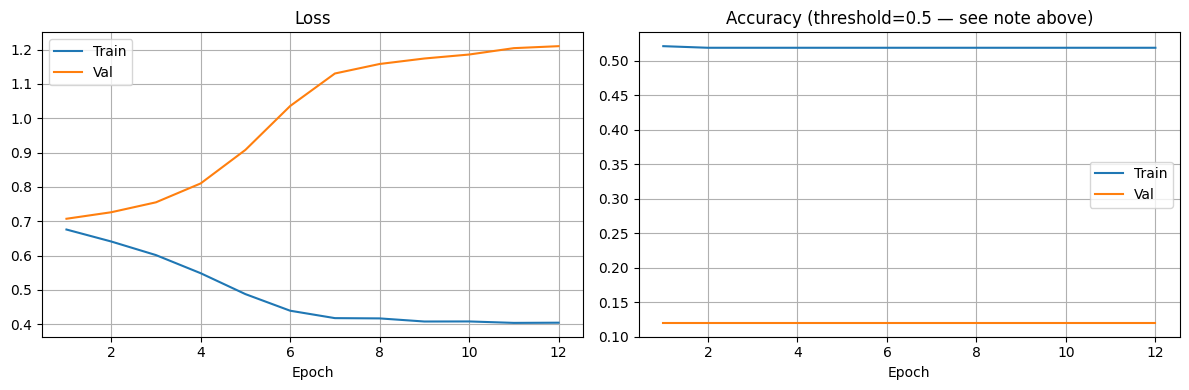


TEST RESULTS  (threshold=0.2)
ACC    : 0.1333
BACC   : 0.5000
AUC    : 0.4784
Recall  class0=1.0000  class1=0.0000
Precision class0=0.1333  class1=0.0000
Macro-F1: 0.1176
Confusion (tn,fp,fn,tp): 16,0,104,0

                  precision    recall  f1-score   support

Non-survivor (0)       0.13      1.00      0.24        16
    Survivor (1)       0.00      0.00      0.00       104

        accuracy                           0.13       120
       macro avg       0.07      0.50      0.12       120
    weighted avg       0.02      0.13      0.03       120



/home/yona/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/yona/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/yona/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


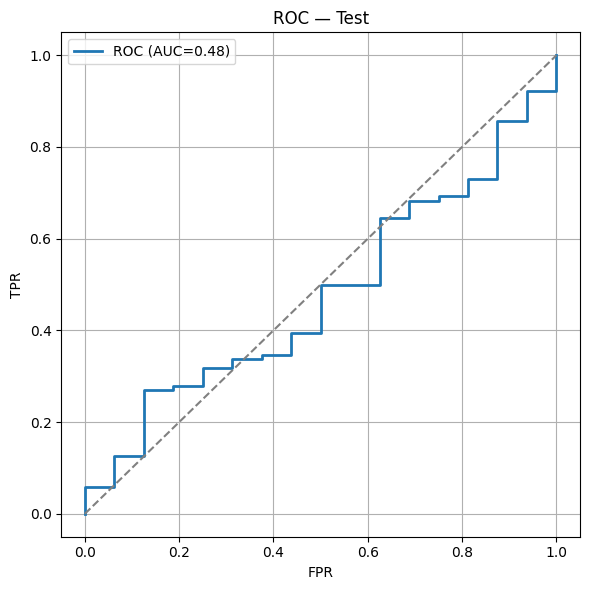

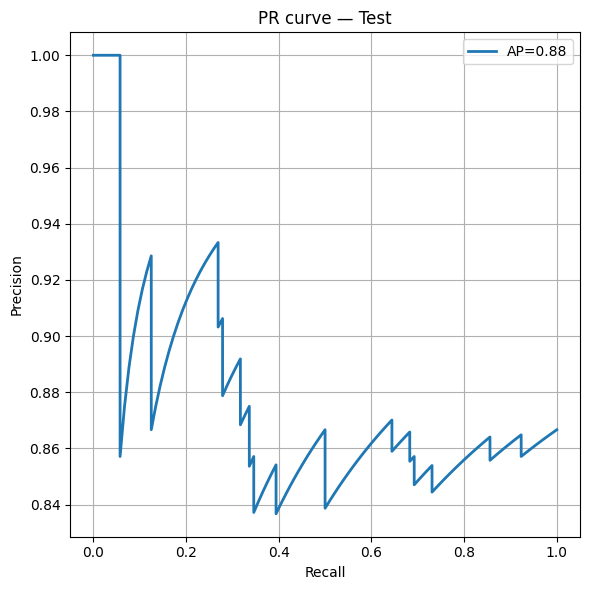

In [23]:

CFG = {
    'final_triplet_path': f'{DATA_ROOT}/triplet_model_final_trainval.pth',
    'hidden_dims':        [512, 64, 512],
    'dropouts':           [0.5630113519488746, 0.34701149217620697, 0.20170906968702756],
    'lr':                 1.6913245547160562e-05,
    'weight_decay':       3.7190395920084656e-08,
    'batch_size':         8,
    'noise_std':          0.02,
    'augment_factor':     8,
    'num_epochs':         12,
    'threshold':          0.2,
    'val_split':          'validation',
    'seed':               42,
}
set_seed(CFG['seed'])
triplet_model, _ = load_triplet_model(CFG['final_triplet_path'])

Z_train, y_train, pid_train = extract_embeddings('train',         triplet_model)
Z_val,   y_val,   pid_val   = extract_embeddings(CFG['val_split'], triplet_model)
Z_test,  y_test,  pid_test  = extract_embeddings('test',          triplet_model)

X_train_agg, y_train_agg = aggregate_maxpool(Z_train, y_train, pid_train)
X_val_agg,   y_val_agg   = aggregate_maxpool(Z_val,   y_val,   pid_val)
X_test_agg,  y_test_agg  = aggregate_maxpool(Z_test,  y_test,  pid_test)
print(f'Patients — train:{X_train_agg.shape[0]} val:{X_val_agg.shape[0]} test:{X_test_agg.shape[0]}')

tr_ds  = AugmentedPatientDataset(X_train_agg, y_train_agg, augment=True,  noise_std=CFG['noise_std'], augment_factor=CFG['augment_factor'])
va_ds  = AugmentedPatientDataset(X_val_agg,   y_val_agg,   augment=False)
te_ds  = AugmentedPatientDataset(X_test_agg,  y_test_agg,  augment=False)
tr_ld  = DataLoader(tr_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=0)
va_ld  = DataLoader(va_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=0)
te_ld  = DataLoader(te_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=0)

model  = PatientMLP(X_train_agg.shape[1], CFG['hidden_dims'], CFG['dropouts']).to(device)
cc     = np.bincount(y_train_agg.astype(int))
w      = torch.tensor([1.0/max(cc[0],1), 1.0/max(cc[1],1)], dtype=torch.float32).to(device)
crit   = nn.CrossEntropyLoss(weight=w)
opt    = optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)

train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(CFG['num_epochs']):
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    for Xb, yb in tr_ld:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(Xb)
        loss   = crit(logits, yb)
        loss.backward()
        opt.step()
        run_loss += loss.item() * Xb.size(0)
        correct  += (logits.argmax(1) == yb).sum().item()
        total    += yb.size(0)
    tr_loss = run_loss / max(total, 1)
    tr_acc  = correct  / max(total, 1)

    model.eval()
    with torch.no_grad():
        run_loss, correct, total = 0.0, 0, 0
        for Xb, yb in va_ld:
            Xb, yb = Xb.to(device), yb.to(device)
            logits  = model(Xb)
            run_loss += crit(logits, yb).item() * Xb.size(0)
            correct  += (logits.argmax(1) == yb).sum().item()
            total    += yb.size(0)
    va_loss = run_loss / max(total, 1)
    va_acc  = correct  / max(total, 1)

    sched.step(va_loss)
    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(va_loss);   val_accs.append(va_acc)
    print(f'Epoch {epoch+1}/{CFG["num_epochs"]} | '
          f'Train Loss={tr_loss:.4f} Acc={tr_acc:.4f} || '
          f'Val Loss={va_loss:.4f} Acc={va_acc:.4f}')

epochs = range(1, CFG['num_epochs'] + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_losses, label='Train'); axes[0].plot(epochs, val_losses, label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True); axes[0].legend()
axes[1].plot(epochs, train_accs,  label='Train'); axes[1].plot(epochs, val_accs,  label='Val')
axes[1].set_title('Accuracy (threshold=0.5 — see note above)')
axes[1].set_xlabel('Epoch'); axes[1].grid(True); axes[1].legend()
plt.tight_layout(); plt.show()


# ── Test evaluation ──
model.eval()
ys, p1s = [], []
with torch.no_grad():
    for Xb, yb in te_ld:
        p1s.append(F.softmax(model(Xb.to(device)), dim=1)[:, 1].cpu().numpy())
        ys.append(yb.numpy())
y_true = np.concatenate(ys).astype(int)
p1     = np.concatenate(p1s).astype(float)
thr    = CFG['threshold']
y_pred = (p1 > thr).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
recall_0    = tn / (tn + fp + 1e-12)
recall_1    = tp / (tp + fn + 1e-12)
precision_0 = tn / (tn + fn + 1e-12)
precision_1 = tp / (tp + fp + 1e-12)
bacc        = 0.5 * (recall_0 + recall_1)
f1_0        = 2*precision_0*recall_0/(precision_0+recall_0+1e-12)
f1_1        = 2*precision_1*recall_1/(precision_1+recall_1+1e-12)
auc_score   = roc_auc_score(y_true, p1)

print(f'\nTEST RESULTS  (threshold={thr})')
print(f'ACC    : {accuracy_score(y_true, y_pred):.4f}')
print(f'BACC   : {bacc:.4f}')
print(f'AUC    : {auc_score:.4f}')
print(f'Recall  class0={recall_0:.4f}  class1={recall_1:.4f}')
print(f'Precision class0={precision_0:.4f}  class1={precision_1:.4f}')
print(f'Macro-F1: {0.5*(f1_0+f1_1):.4f}')
print(f'Confusion (tn,fp,fn,tp): {tn},{fp},{fn},{tp}')
print()
print(classification_report(y_true, y_pred, target_names=['Non-survivor (0)', 'Survivor (1)']))

fpr, tpr, _ = roc_curve(y_true, p1)
roc_auc     = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC — Test'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_true, p1)
ap = average_precision_score(y_true, p1)
plt.figure(figsize=(6, 6))
plt.plot(recall_curve, precision_curve, lw=2, label=f'AP={ap:.2f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR curve — Test'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()
